In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_csv('../data/raw/customers.csv')
orders = pd.read_csv('../data/raw/orders.csv')
partners = pd.read_csv('../data/raw/partners.csv')
payments = pd.read_csv('../data/raw/payments.csv')
restaurants = pd.read_csv('../data/raw/restaurants.csv')

In [4]:
customers.info()
orders.info()
partners.info()
payments.info()
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    1000 non-null   object
 1   customer_name  1000 non-null   object
 2   city           1000 non-null   object
 3   age            1000 non-null   int64 
 4   gender         1000 non-null   object
 5   signup_date    1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               10000 non-null  object 
 1   customer_id            10000 non-null  object 
 2   restaurant_id          10000 non-null  object 
 3   partner_id             10000 non-null  object 
 4   order_date             10000 non-null  object 
 5   order_value            

In [5]:
customers.shape
restaurants.shape
payments.shape
partners.shape
orders.shape

(10000, 11)

In [6]:
# ----- Missing Values -----
customers.isnull().sum()
restaurants.isnull().sum()
orders.isnull().sum()
payments.isnull().sum()
partners.isnull().sum()


partner_id       0
partner_name     0
city             0
Vehicle_Types    0
Experience       0
Joining_date     0
dtype: int64

In [7]:
customers.duplicated().sum()

restaurants.duplicated().sum()

orders.duplicated().sum()

payments.duplicated().sum()

partners.duplicated().sum()

0

In [8]:
customers.dtypes

restaurants.dtypes

orders.dtypes

payments.dtypes

partners.dtypes

partner_id       object
partner_name     object
city             object
Vehicle_Types    object
Experience        int64
Joining_date     object
dtype: object

In [9]:
master_df = (
    orders
    .merge(customers, on="customer_id")
    .merge(restaurants.rename(columns={"partner_id": "partners_id"}), on="restaurant_id")
    .merge(partners, on="partner_id")
    .merge(payments, on="order_id")
)



In [10]:
#master_df.head()
master_df.shape
master_df.columns
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               10000 non-null  object 
 1   customer_id            10000 non-null  object 
 2   restaurant_id          10000 non-null  object 
 3   partner_id             10000 non-null  object 
 4   order_date             10000 non-null  object 
 5   order_value            10000 non-null  int64  
 6   company_commission     10000 non-null  float64
 7   delivery_fee           10000 non-null  int64  
 8   delivery_time_minutes  9196 non-null   float64
 9   order_status           10000 non-null  object 
 10  customer_rating        9196 non-null   float64
 11  customer_name          10000 non-null  object 
 12  city_x                 10000 non-null  object 
 13  age                    10000 non-null  int64  
 14  gender                 10000 non-null  object 
 15  sig

In [11]:
master_df.rename(columns={
    "city_x" : "customer_city", 
    "city_y" : "restaurant_city",
    "city" : "partner_city"
},inplace = True)

In [12]:
(master_df["partner_id"] == master_df["partners_id"]).all()
master_df.drop(columns="partners_id", inplace=True)

In [13]:
master_df["rating"].dtype
master_df["rating"].dtype


dtype('O')

In [14]:
master_df['order_date'] = pd.to_datetime(master_df['order_date'])
master_df['signup_date'] = pd.to_datetime(master_df['signup_date'])
master_df['Joining_date'] = pd.to_datetime(master_df['Joining_date'])
master_df['partner_since'] = pd.to_datetime(master_df['partner_since'])
master_df['payment_date'] = pd.to_datetime(master_df['payment_date'])

In [15]:
# ---- Executive KPIs ----
print("----------KPIs----------")
print(f"Total Revenue - {master_df['order_value'].sum()}")
print(f"Company Revenue - {master_df['company_commission'].sum()}")
print(f"Total Orders - {master_df['order_id'].nunique()}")
print(f"Total Customers - {master_df['customer_id'].nunique()}")
print(f"Total Restaurants : {master_df['restaurant_id'].nunique()}")
print(f"Total Partners : {master_df['partner_id'].nunique()}")
print(f"Average Order Value - {master_df['order_value'].mean()}")
print(f"Delivered Rate - {(master_df['order_status'] == 'Delivered').mean() * 100}")
print(f"Cancellation Rate - {(master_df['order_status']=='Cancelled').mean() * 100}")



----------KPIs----------
Total Revenue - 6220029
Company Revenue - 1143183.0
Total Orders - 10000
Total Customers - 1000
Total Restaurants : 100
Total Partners : 50
Average Order Value - 622.0029
Delivered Rate - 91.96
Cancellation Rate - 8.04


In [16]:
# --- Revenue By City ----
master_df.groupby("customer_city")["order_value"].sum().sort_values(ascending=False)

customer_city
Chennai      868246
Bangalore    864206
Delhi        841239
Ahmedabad    808506
Mumbai       771946
Hyderabad    724666
Surat        720034
Pune         621186
Name: order_value, dtype: int64

In [17]:
# --- Revenue By Cuisine ----
master_df.groupby("cuisine")["order_value"].sum().sort_values(ascending=False)

cuisine
Mexican           930196
Chinese           854564
Biryani           810981
South Indian      754024
North Indian      740155
SizzlerItalian    689314
Nachos            641077
Gujarati          421021
Pizza             378697
Name: order_value, dtype: int64

In [18]:
# ----- Top 10 Customers -----
master_df.groupby("customer_id")["order_value"].sum().sort_values(ascending=False).head(10)

customer_id
C0281    15882
C0909    15657
C0583    15576
C0370    14885
C0525    14542
C0729    14106
C0143    14036
C0538    13002
C0465    12900
C0589    12897
Name: order_value, dtype: int64

In [19]:
# --- Top Restaurants -----
master_df.groupby("restaurant_id")["order_value"].sum().sort_values(ascending=False).head(10)

restaurant_id
R0097    77140
R0009    76902
R0093    76823
R0090    76228
R0028    75664
R0042    75608
R0032    75201
R0072    75170
R0007    74484
R0100    74459
Name: order_value, dtype: int64

In [20]:
# --- Revenue By City ---
master_df.groupby("customer_city")["order_value"].sum().sort_values(ascending=False)

customer_city
Chennai      868246
Bangalore    864206
Delhi        841239
Ahmedabad    808506
Mumbai       771946
Hyderabad    724666
Surat        720034
Pune         621186
Name: order_value, dtype: int64

In [21]:
# --- Orders By City ---
master_df.groupby("customer_city")["order_id"].count().sort_values(ascending=False)

customer_city
Chennai      1382
Bangalore    1352
Delhi        1331
Ahmedabad    1312
Mumbai       1252
Hyderabad    1195
Surat        1144
Pune         1032
Name: order_id, dtype: int64

In [22]:
# --- Revenue By Gender ----
master_df.groupby("gender")["order_value"].sum().sort_values(ascending=False)

gender
Male      3183726
Female    3036303
Name: order_value, dtype: int64

In [23]:
# --- Average Spending By Gender
master_df.groupby("gender")["order_value"].mean().sort_values(ascending=False)

gender
Male      625.240770
Female    618.643643
Name: order_value, dtype: float64

In [24]:
# --- Top 10 Customers ----
master_df.groupby("customer_name")["order_value"].sum().sort_values(ascending=False).head(10)

customer_name
Pranjal    462263
Mahek      424780
Mudra      402076
Siya       395694
Kishan     392548
Aditiya    385846
Arjun      385664
Krishna    373601
Vivan      365929
Ayushi     364812
Name: order_value, dtype: int64

In [25]:
# --- Top Restaurants ---
master_df.groupby("restaurant_name")["order_value"].sum().sort_values(ascending=False).head(10)

restaurant_name
The Green Chutney      1246535
Naan Stop               938706
Dal Roti Wala           916394
Wok & Tikka             811804
Tadka Town              717207
Curry Cartel            590830
The Midnight Masala     558658
The Chaat Chart         439895
Name: order_value, dtype: int64

In [26]:
master_df["rating"].dtype

dtype('O')

In [27]:
# --- Average Restaurant Rating ----
master_df.groupby("restaurant_name")["rating"].count().sort_values(ascending=False).head(10)

restaurant_name
The Green Chutney      2025
Naan Stop              1500
Dal Roti Wala          1466
Wok & Tikka            1322
Tadka Town             1130
Curry Cartel            967
The Midnight Masala     894
The Chaat Chart         696
Name: rating, dtype: int64

In [28]:
# --- Average Delivery Time ----
master_df["delivery_time_minutes"].mean()

39.90300130491518

In [29]:
# --- Average Delivery Time By City ----
master_df.groupby("customer_city")["delivery_time_minutes"].mean().sort_values(ascending=False)

customer_city
Surat        40.150239
Chennai      40.102767
Ahmedabad    40.022613
Bangalore    39.988827
Hyderabad    39.882299
Mumbai       39.823224
Pune         39.804069
Delhi        39.461355
Name: delivery_time_minutes, dtype: float64

In [30]:
# --- Cancellation Rate ----
master_df.groupby("customer_city")["order_status"].apply(lambda x: (x=="Cancelled").mean()).sort_values(ascending=False)

customer_city
Pune         0.094961
Ahmedabad    0.089939
Surat        0.086538
Chennai      0.084660
Hyderabad    0.082845
Mumbai       0.078275
Bangalore    0.073225
Delhi        0.057100
Name: order_status, dtype: float64

In [31]:
# ---- Payment Method Distribution ---
#master_df.groupby("payment_method")["order_value"].sum().sort_values(ascending=False)
master_df["payment_method"].value_counts()

payment_method
UPI            7015
COD            1498
Credit Card     969
Debit Card      518
Name: count, dtype: int64

In [32]:
# --- Payment Revenue ----
master_df.groupby("payment_method")["payment_amount"].sum().sort_values(ascending=False)

payment_method
UPI            4557351
COD             995248
Credit Card     635273
Debit Card      340667
Name: payment_amount, dtype: int64

In [33]:
master_df["Month"] = master_df["order_date"].dt.to_period("M")

master_df.groupby("Month")["order_value"] \
.sum()

Month
2024-06     63985
2024-07    296304
2024-08    258727
2024-09    232410
2024-10    258863
2024-11    246454
2024-12    253990
2025-01    249582
2025-02    224995
2025-03    291193
2025-04    253804
2025-05    261923
2025-06    259195
2025-07    254861
2025-08    269488
2025-09    256506
2025-10    279440
2025-11    254236
2025-12    258338
2026-01    260122
2026-02    230144
2026-03    299569
2026-04    259249
2026-05    254124
2026-06    192527
Freq: M, Name: order_value, dtype: int64

In [34]:
# --- Monthly Orders ----
master_df.groupby("Month")["order_id"].count().sort_values(ascending=False)

Month
2025-10    454
2025-03    452
2024-07    446
2026-03    445
2025-08    436
2024-08    433
2025-11    429
2025-09    428
2026-01    427
2025-12    422
2025-01    413
2024-12    413
2024-10    413
2025-06    412
2026-05    409
2025-07    407
2024-11    402
2025-04    401
2026-04    400
2025-05    398
2024-09    391
2026-02    378
2025-02    365
2026-06    318
2024-06    108
Freq: M, Name: order_id, dtype: int64

In [35]:
# Day of week
master_df["Weekday"] = master_df["order_date"].dt.day_name()

# Month name
master_df["Month_Name"] = master_df["order_date"].dt.month_name()

# Order category
master_df["Order_Size"] = np.where(
    master_df["order_value"] > 1000,
    "High",
    "Low"
)

# Weekend order
master_df["Is_Weekend"] = master_df["Weekday"].isin(["Saturday", "Sunday"])

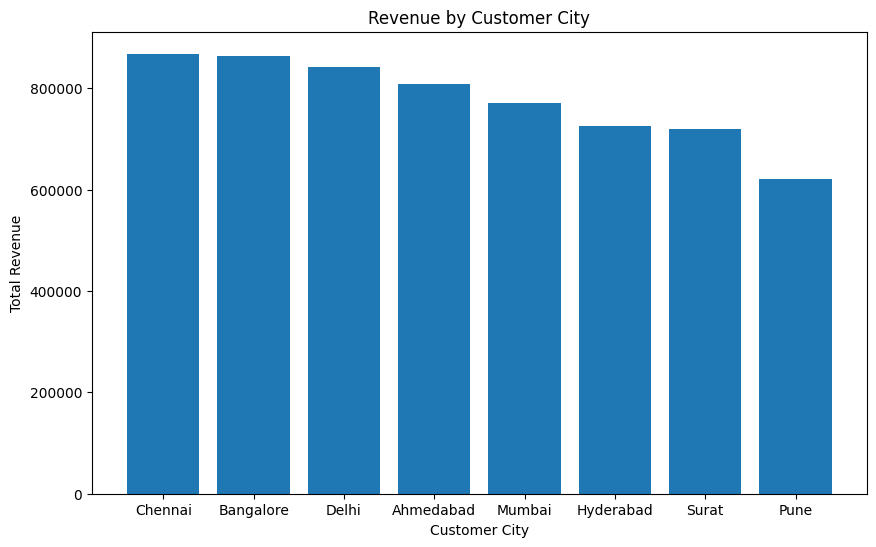

In [36]:
city_revenue = master_df.groupby("customer_city")["order_value"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(city_revenue.index, city_revenue.values)
plt.xlabel("Customer City")
plt.ylabel("Total Revenue")
plt.title("Revenue by Customer City")
plt.show()

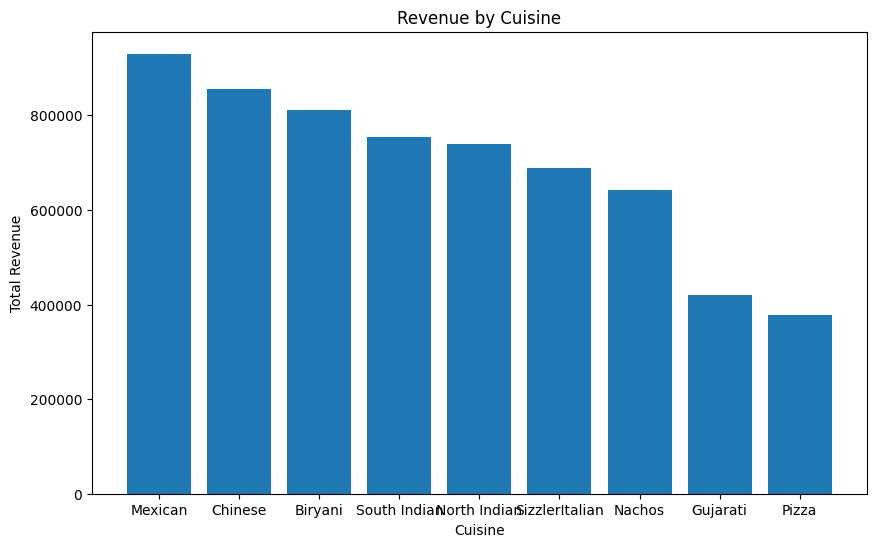

In [37]:
Revenue_Cuisine = master_df.groupby("cuisine")["order_value"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(Revenue_Cuisine.index, Revenue_Cuisine.values)
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.title("Revenue by Cuisine")
plt.show()

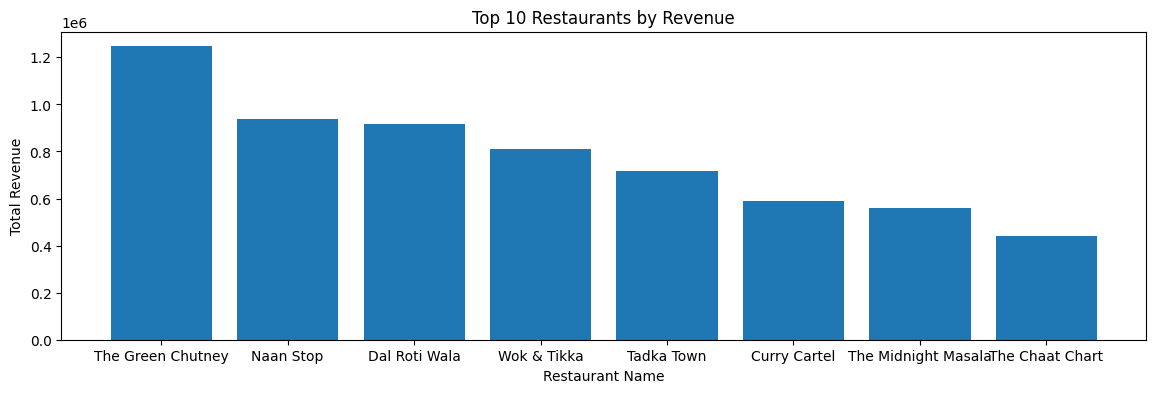

In [38]:
top_restaurants = master_df.groupby("restaurant_name")["order_value"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(14,4))
plt.bar(top_restaurants.index, top_restaurants.values)
plt.xlabel("Restaurant Name")
plt.ylabel("Total Revenue")
plt.title("Top 10 Restaurants by Revenue")
plt.show()

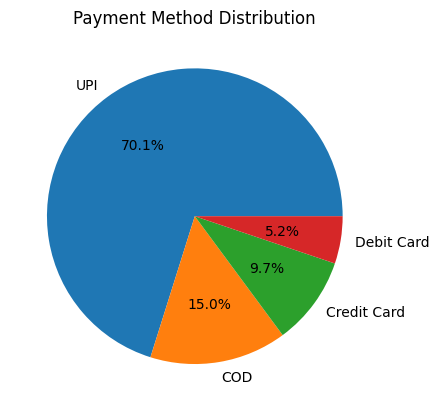

In [39]:
master_df["payment_method"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

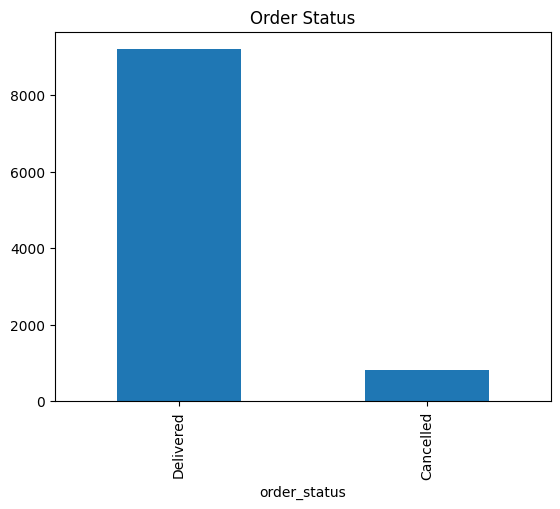

In [40]:
master_df["order_status"].value_counts().plot(
    kind="bar"
)

plt.title("Order Status")
plt.show()

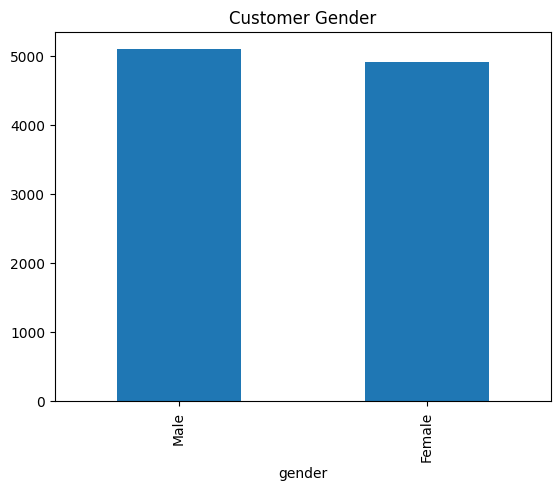

In [41]:
master_df["gender"].value_counts().plot(kind="bar")

plt.title("Customer Gender")
plt.show()

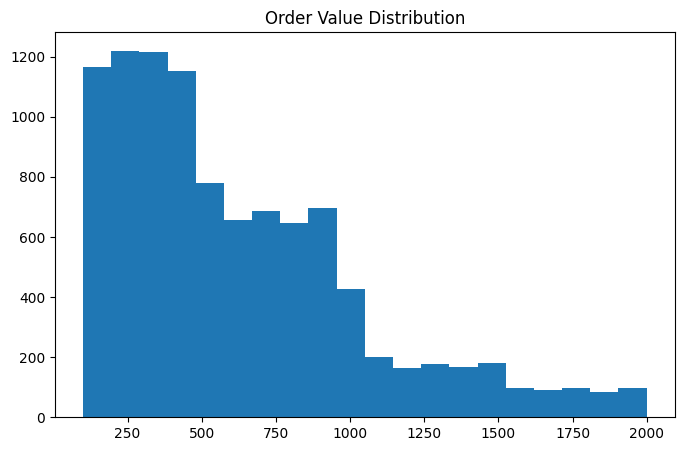

In [42]:
plt.figure(figsize=(8,5))

plt.hist(master_df["order_value"],bins=20)

plt.title("Order Value Distribution")

plt.show()

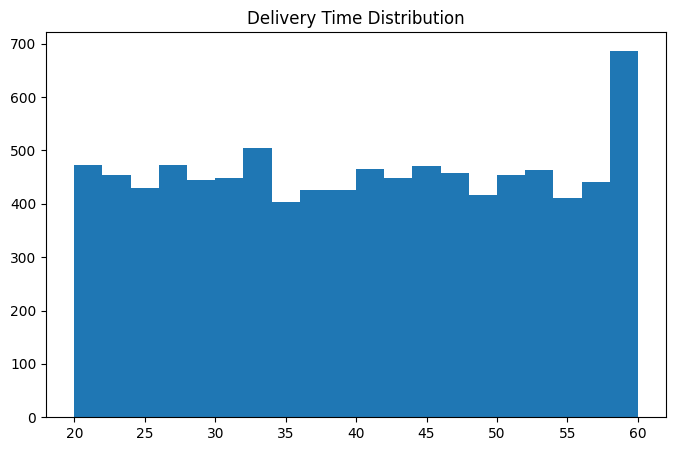

In [43]:
plt.figure(figsize=(8,5))

plt.hist(
    master_df["delivery_time_minutes"].dropna(),
    bins=20
)

plt.title("Delivery Time Distribution")

plt.show()

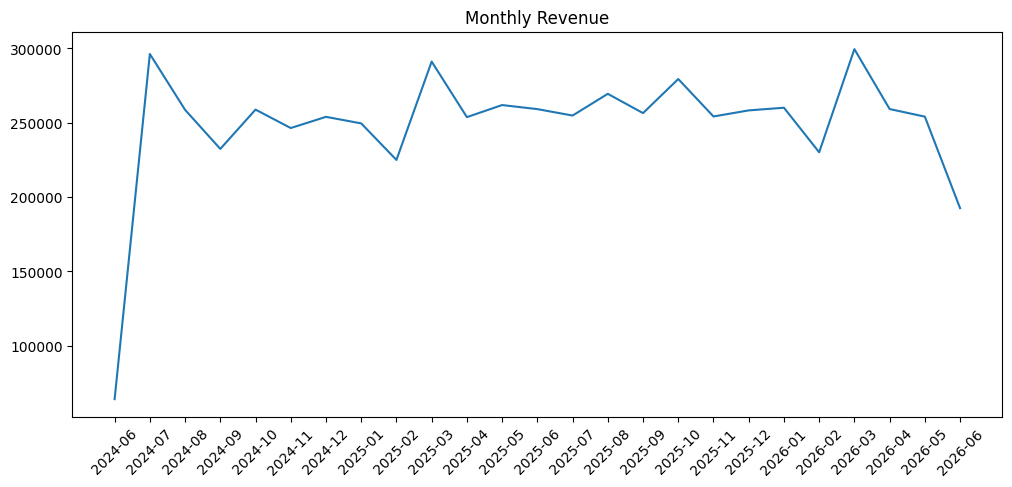

In [44]:
monthly = master_df.groupby("Month")["order_value"].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly.index.astype(str),monthly.values)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.show()

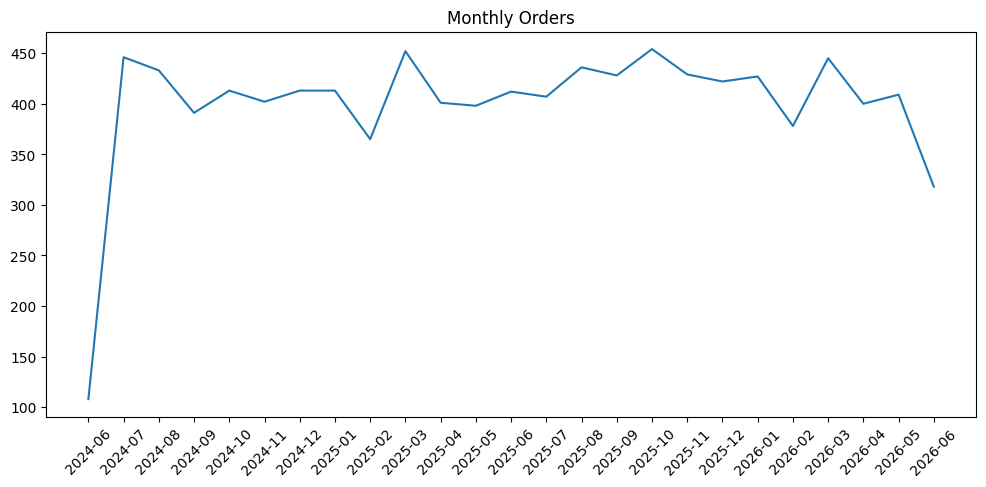

In [45]:
monthly_orders = master_df.groupby("Month")["order_id"].count()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values
)

plt.xticks(rotation=45)

plt.title("Monthly Orders")

plt.show()

In [47]:
master_df.to_csv('../data/raw/master_data.csv' , index=False)
print("Data Saved Succesfully")

Data Saved Succesfully
